# Cancer Classification Model Using Gene Expression Data

---
embed-resources: true
echo: false
---

## Introduction

In this report, I will explore whether gene expression data can be used to help detect cancer by building a machine learning model. As a data scientist at a biotechnology startup, my goal is to build a simple proof of concept model that uses gene expression data collected from next-generation sequencing to predict whether cancer is present. The dataset contains expression levels for many genes along with a cancer label indicating whether cancer is present. I use this data to train and develop a classification model that estimates cancer risk from genetic patterns. My goal in this report is not to create a finished medical tool but to assess whether gene expression data contains enough signal to support early cancer detection and justify further development.

## Methods

In order to develop a machine learning model that predict whether cancer is present, I use gene expression and clinical outcome data collected through next-generation sequencing and train a gradient boosted tree classifier using tools provided by scikit-learn.

In [1]:
#imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

### Data

In [3]:
# load data
#| echo: true
genetics = pd.read_parquet(
    "https://lab.cs307.org/genetics/data/genetics.parquet",
)

In [4]:
# create X and y
X = genetics.drop("cancer",axis=1)
y = genetics["cancer"]

In [5]:
# train-test split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42, stratify=y)

In this report, I use a gene expression dataset collected from next-generation sequencing experiments. Each observation represents a single biological sample and the features correspond to measured gene expression levels such as "gene_####". The target variable "cancer" indicates whether the sample is associated with cancer. This dataset allows me to study how patterns in gene expression differ between cancer and non-cancer samples. To support unbiased model evaluation, I split the data into training and test sets while making sure the class proportions stay the same in both.

The goal of my analysis is to use these gene expression profiles to predict whether a biological sample is associated with cancer so understanding the available variables is important. A full description of the features used in this model is provided in the data dictionary below.

**Data Dictionary:**

- Target variable (object):
  - cancer: the clinically determined cancer type associated with the tissue sample, possible values include:
    - BRCA: Breast Invasive Carcinoma
    - PRAD: Prostate Adenocarcinoma
    - KIRC: Kidney Renal Clear Cell Carcinoma
    - LUAD: Lung Adenocarcinoma
    - COAD: Colon Adenocarcinoma

- Features (float64):
  - gene_####: continuous gene expression measurement for gene number #### in the dataset.
These values represent quantified expression levels obtained using an Illumina HiSeq next-generation sequencing platform.

In [8]:
#| label: tbl-cancer
#| tbl-cap: "Distribution of cancer types"
cancer_counts = y.value_counts()
cancer_props = y.value_counts(normalize=True)
summary_table = (pd.DataFrame({"Cancer Type": cancer_counts.index,"Count": cancer_counts.values,"Proportion": cancer_props.values}))
summary_table

,Cancer Type,Count,Proportion
0,BRCA,300,0.374532
1,KIRC,146,0.182272
2,LUAD,141,0.176030
3,PRAD,136,0.169788
4,COAD,78,0.097378


@tbl-cancer shows the distribution of cancer types in the dataset. For each cancer type, I report the total number of samples and the proportion of the dataset it represents. This helps me understand the class balance and see which cancer types are more or less common before building and evaluating the model.

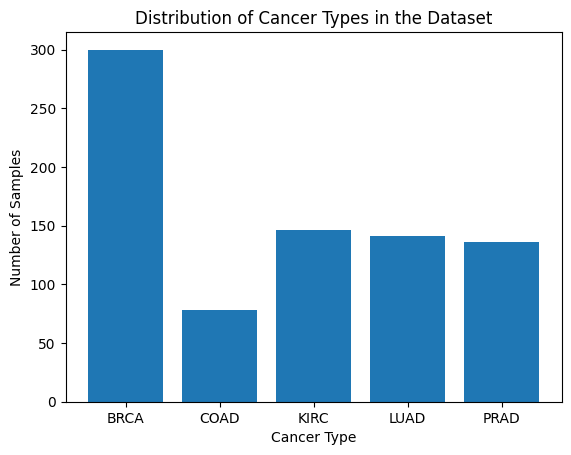

In [9]:
#| label: fig-cancer-dist
#| fig-cap: "Distribution of cancer types in the gene expression dataset"
import matplotlib.pyplot as plt
class_counts = y.value_counts().sort_index()
plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.title("Distribution of Cancer Types in the Dataset")
plt.show()

@fig-cancer-dist shows the distribution of cancer types in the gene expression dataset. We can see that some cancer types appear much more often than others which means the data is imbalanced. This is important to consider because it can influence how the model learns and how accuracy is interpreted especially if the model ends up favoring the most common cancer types.

### Modeling

To develop a proof of concept cancer classification model, I used a Histogram Gradient Boosting Classifier which works well with gene expression data with a very large number of features and can model complex, non-linear relationships between genes and cancer outcomes. This model was chosen because it performs efficiently on large datasets and does not require feature scaling.

Before modeling, missing gene expression values were handled using median imputation strategy which is a simple and reliable way to handle missing data without being affected by extreme values. I then combined the imputer and the classifier into one scikit-learn pipeline so that the same preprocessing steps were applied consistently during both training and testing.

In [13]:
# create a modeling pipeline that imputes missing gene expression values using the median and trains a Histogram Gradient Boosting Classifier
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

After that, to improve performance, I tuned some key hyperparameters using GridSearchCV with 5-fold cross-validation. Specifically, I tuned the learning rate, the maximum depth of the trees and the number of boosting iterations. These paramters control how fast the model learns, how complex each tree is and how large the overall model becomes.

In [10]:
#| echo: true
# define the parameter grid
param_grid = {
    "model__learning_rate": [0.1,0.25],
    "model__max_depth": [2,3],
    "model__max_iter": [300, 500],
}

In [14]:
#| echo: true
# create the grid search
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

During tuning, I measure performance using accuracy metrics since the main goal of building this model is to correctly classify whether cancer is present. The best-performing model was selected and refit on the training dataset.

In [15]:
#| label: fig-model
#| fig-cap: #| fig-cap: "The modeling pipeline used for cancer classification based on gene expression data including missing value imputation and a Histogram Gradient Boosting classifier trained with cross-validation."
grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.1, 0.25], 'model__max_depth': [2, 3], 'model__max_iter': [300, 500]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


## Results

In [17]:
ytestpred =  grid.predict(X_test)
t= accuracy_score(y_test,ytestpred)
print(f"Test Accuracy: {t}")

Test Accuracy: 0.9850746268656716


The dataset was split into training and test sets using a stratified split so the class distribution stayed the same giving a fair estimate of how well the model works on new data. After tuning the model using GridSearchCV with cross-validation, I evaluated the final selected model on the test dataset. The model achieved a test accuracy of approximately 0.985 meaning it correctly classifies cancer types for about 98.5% of the samples. 

Accuracy was an appropriate evaluation metric for this model because the goal of the model is to correctly classify whether a sample is associated with cancer. Because the outcome is a categorical label and the main goal is correct classification, accuracy is a clear and easy to understand measure of performance. It shows how often the model makes the right prediction on unseen data which fits well with measuring the model as a proof of concept cancer detection tool.

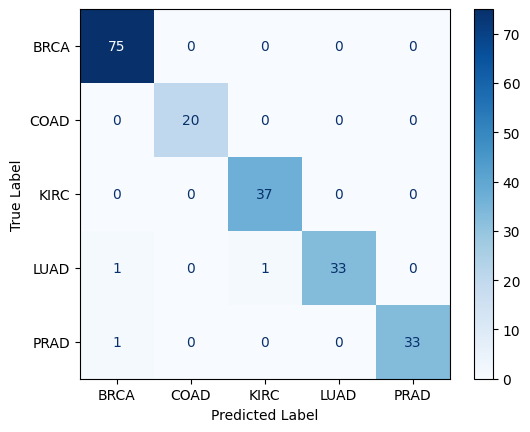

In [ ]:
#| label: fig-confusion
#| fig-cap: "Confusion matrix showing the classification performance of the final gradient boosted tree model on the test dataset"
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions( y_test, ytestpred, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

@fig-confusion is a confusion matrix shows how well the final model performs on unseen test data. Most predictions fall along the diagonal indicating that the model correctly classifies the majority of samples for each cancer type. Very few misclassifications appear and when they do, they are limited to a small number of cases. In general, this confusion matrix shows that the model has high test accuracy and performs well across different cancer classes.

## Discussion

**Conclusion:** Based on the results of this analysis, I would use the trained gradient boosted tree model as a proof of concept but not as a final tool for real clinical decisions. The model achieved very high test accuracy about 98.5% and the confusion matrix shows that most cancer types were classified correctly. This suggests that gene expression data contains strong patterns that can be used to distinguish between different cancers which supports the overall goal of this project.

**Benefits:** The main benefit of this model is that it can accurately classify cancer types using gene expression measurements. In practice, a model like this could help researchers or clinicians narrow down possible cancer types or support early screening when combined with other medical tests. Because the data was split into training and test sets and the model was tuned using cross-validation, the performance results give a reasonable estimate of how the model would perform on new and unseen data.

**Limitations:** However, there are important limitations to consider. Accuracy alone does not show what kinds of mistakes the model makes. In a medical setting, even a small number of errors can be serious. For example, predicting the wrong cancer type could delay proper treatment or lead to unnecessary tests. While these errors are rare in this model, I believe their potential impact could still be significant. In addition, the model does not explain why it makes certain predictions which makes it harder to trust or use in real-world situations.

Another limitation is that the model only uses gene expression data and does not include other patient information such as medical history or clinical features. To improve this work, future models could include more types of data, take a closer look at mistakes for each cancer type and better explain which genes influence the predictions. The model would also need to be tested on outside datasets before it could be used in the real world.